<a href="https://colab.research.google.com/github/lack-of-sleep/2023-1-UPP/blob/main/apling_hw02_CoLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#set up the BERT model
#BERT_model = 'bert-base-uncased'
BERT_model = 'bert-large-uncased'

In [ ]:
import tensorflow as tf
import torch

In [ ]:
#get the GPU device name
device_name = tf.test.gpu_device_name()

In [ ]:
if device_name == '/device:GPU:0':
  print('Found GPU at: {}'.format(device_name))
else:
  raise SystemError('GPU device not found')

Found GPU at: /device:GPU:0


In [ ]:
if torch.cuda.is_available():
  device = torch.device("cuda")
  print('There are %d GPU(s) available.' % torch.cuda.device_count())
  print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
  print('No GPU available, using the CPU instead.')
  device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla T4


In [ ]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 88.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 103.6 MB/s eta 0:00:00


In [ ]:
!pip install wget

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9657 sha256=331df7c458f3747353127b45c09904a877493c78742628dadb5dac781169254b
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


In [ ]:
import os
import wget

In [ ]:
print('Downloading dataset...')
url = 'https://nyu-mll.github.io/CoLA/cola_public_1.1.zip'
if not os.path.exists('./cola_public_1.1.zip'):
  wget.download(url, './cola_public_1.1.zip')

In [ ]:
if not os.path.exists('./cola_public/'):
  !unzip cola_public_1.1.zip

Archive:  cola_public_1.1.zip
   creating: cola_public/
  inflating: cola_public/README      
   creating: cola_public/tokenized/
  inflating: cola_public/tokenized/in_domain_dev.tsv  
  inflating: cola_public/tokenized/in_domain_train.tsv  
  inflating: cola_public/tokenized/out_of_domain_dev.tsv  
   creating: cola_public/raw/
  inflating: cola_public/raw/in_domain_dev.tsv  
  inflating: cola_public/raw/in_domain_train.tsv  
  inflating: cola_public/raw/out_of_domain_dev.tsv  


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("./cola_public/raw/in_domain_train.tsv", delimiter='\t', header=None, names=['sentence_source', 'label', 'label_notes', 'sentence'])

In [ ]:
print('Number of training sentences: {:,}\n'.format(df.shape[0]))

Number of training sentences: 8,551



In [ ]:
df.head()

,sentence_source,label,label_notes,sentence
0,gj04,1,NaN,"Our friends won't buy this analysis, let alone..."
1,gj04,1,NaN,One more pseudo generalization and I'm giving up.
2,gj04,1,NaN,One more pseudo generalization or I'm giving up.
3,gj04,1,NaN,"The more we study verbs, the crazier they get."
4,gj04,1,NaN,Day by day the facts are getting murkier.


In [ ]:
sentences = df.sentence.values
labels = df.label.values

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer

In [ ]:
tokenizer = BertTokenizer.from_pretrained(BERT_model, do_lower_case=True)

In [ ]:
input_ids = []
for sent in sentences:
  encoded_sent = tokenizer.encode( sent, add_special_tokens = True)
  input_ids.append(encoded_sent)

In [ ]:
print('Original: ', sentences[0])
print('Token IDs:', input_ids[0])

Original:  Our friends won't buy this analysis, let alone the next one we propose.
Token IDs: [101, 2256, 2814, 2180, 1005, 1056, 4965, 2023, 4106, 1010, 2292, 2894, 1996, 2279, 2028, 2057, 16599, 1012, 102]


In [ ]:
print('Max length: ', max([len(sen) for sen in input_ids]))

Max length:  47


In [ ]:
MAX_LEN = 64
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", value=0, truncating="post", padding="post")

In [ ]:
attention_masks = []
for sent in input_ids:
  att_mask = [int(token_id > 0) for token_id in sent]
  attention_masks.append(att_mask)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(input_ids, labels, random_state=13, test_size=0.1)
train_masks, validation_masks, _, _ = train_test_split(attention_masks, labels, random_state=13, test_size=0.1)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

In [ ]:
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)

In [ ]:
train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)

In [ ]:
train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

In [ ]:
batch_size = 32

In [ ]:
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

In [ ]:
validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [ ]:
from transformers import AdamW, BertConfig, BertForSequenceClassification

In [ ]:
model = BertForSequenceClassification.from_pretrained(BERT_model, num_labels = 2, output_attentions = False, output_hidden_states = False)

Some weights of the model checkpoint at bert-large-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint a

In [ ]:
model.cuda()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,

In [ ]:
from transformers import get_linear_schedule_with_warmup

In [ ]:
optimizer = AdamW(model.parameters(), lr = 2e-5, eps = 1e-8 )

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:407: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
epochs = 4
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0, num_training_steps = total_steps)

In [ ]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
import seaborn as sns
import time

In [ ]:
def flat_accuracy(preds, labels):
  pred_flat = np.argmax(preds, axis=1).flatten()
  labels_flat = labels.flatten()
  return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [ ]:
def format_time(elapsed):
  elapsed_rounded = int(round((elapsed)))
  return str(datetime.timedelta(seconds=elapsed_rounded))

In [ ]:
seed_val = 13
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

In [ ]:
loss_values = []
for epoch_i in range(0, epochs):
  print("")
  print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
  print('Training...')

  t0 = time.time()
  total_loss = 0
  model.train()

  for step, batch in enumerate(train_dataloader):
    if step % 40 == 0 and not step == 0:
      elapsed = format_time(time.time() - t0)
      print(' Batch {:>5,} of {:>5,}. Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    model.zero_grad()
    outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
    loss = outputs[0]
    total_loss += loss.item()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
  avg_train_loss = total_loss / len(train_dataloader)
  loss_values.append(avg_train_loss)
  print("")
  print(" Average training loss: {0:.2f}".format(avg_train_loss))
  print(" Training epcoh took: {:}".format(format_time(time.time() - t0)))
  print("")
  print("Running Validation...")

  t0 = time.time()

  model.eval()

  eval_loss, eval_accuracy = 0, 0
  nb_eval_steps, nb_eval_examples = 0, 0

  for batch in validation_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch
    with torch.no_grad():
      outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    logits = outputs[0]
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    tmp_eval_accuracy = flat_accuracy(logits, label_ids)
    eval_accuracy += tmp_eval_accuracy
    nb_eval_steps += 1
  print(" Accuracy: {0:.2f}".format(eval_accuracy/nb_eval_steps))
  print(" Validation took: {:}".format(format_time(time.time() - t0)))

print("")
print("Training complete!")



======== Epoch 1 / 4 ========
Training...
 Batch    40 of   241. Elapsed: 0:00:48.
 Batch    80 of   241. Elapsed: 0:01:32.
 Batch   120 of   241. Elapsed: 0:02:15.
 Batch   160 of   241. Elapsed: 0:02:59.
 Batch   200 of   241. Elapsed: 0:03:43.
 Batch   240 of   241. Elapsed: 0:04:27.

 Average training loss: 0.45
 Training epcoh took: 0:04:28

Running Validation...
 Accuracy: 0.84
 Validation took: 0:00:10

======== Epoch 2 / 4 ========
Training...
 Batch    40 of   241. Elapsed: 0:00:44.
 Batch    80 of   241. Elapsed: 0:01:28.
 Batch   120 of   241. Elapsed: 0:02:12.
 Batch   160 of   241. Elapsed: 0:02:55.
 Batch   200 of   241. Elapsed: 0:03:39.
 Batch   240 of   241. Elapsed: 0:04:23.

 Average training loss: 0.25
 Training epcoh took: 0:04:24

Running Validation...
 Accuracy: 0.85
 Validation took: 0:00:10

======== Epoch 3 / 4 ========
Training...
 Batch    40 of   241. Elapsed: 0:00:44.
 Batch    80 of   241. Elapsed: 0:01:28.
 Batch   120 of   241. Elapsed: 0:02:12.
 Batch

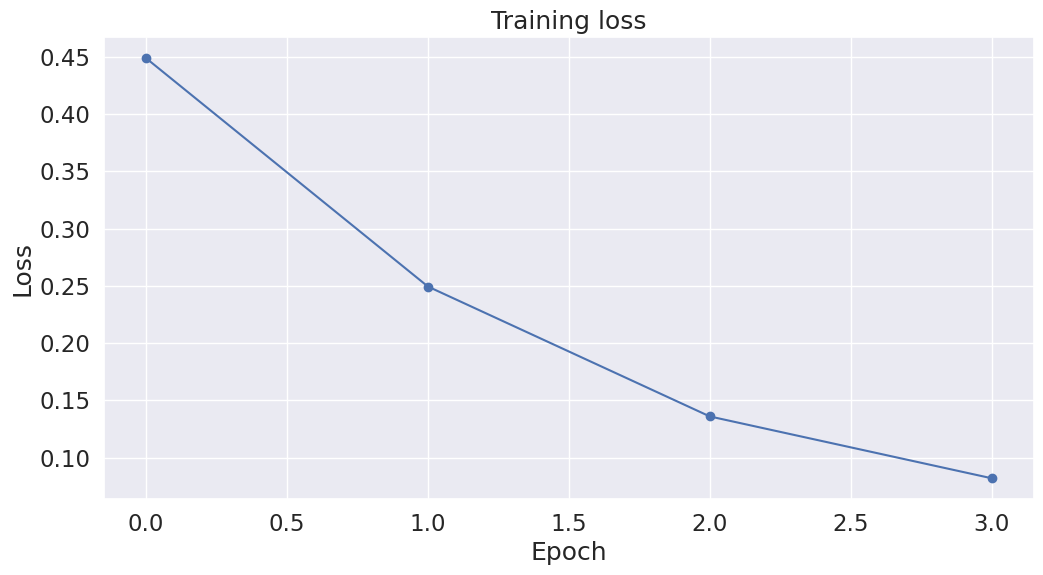

In [ ]:
sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)
plt.plot(loss_values, 'b-o')
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show();

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("./cola_public/raw/out_of_domain_dev.tsv", delimiter='\t', header=None,names=['sentence_source', 'label', 'label_notes', 'sentence'])

In [ ]:
print('Number of test sentences: {:,}\n'.format(df.shape[0]))

Number of test sentences: 516



In [ ]:
sentences = df.sentence.values
labels = df.label.values

In [ ]:
input_ids = []
for sent in sentences:
  encoded_sent = tokenizer.encode(sent, add_special_tokens = True)
  input_ids.append(encoded_sent)

In [ ]:
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [ ]:
attention_masks = []

In [ ]:
for seq in input_ids:
  seq_mask = [float(i>0) for i in seq]
  attention_masks.append(seq_mask)

In [ ]:
prediction_inputs = torch.tensor(input_ids)
prediction_masks = torch.tensor(attention_masks)
prediction_labels = torch.tensor(labels)

In [ ]:
batch_size = 32

In [ ]:
prediction_data = TensorDataset(prediction_inputs, prediction_masks, prediction_labels)
prediction_sampler = SequentialSampler(prediction_data)
prediction_dataloader = DataLoader(prediction_data, sampler=prediction_sampler, batch_size=batch_size)

In [ ]:
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,

In [ ]:
predictions, true_labels = [], []

In [ ]:
for batch in prediction_dataloader:
  batch = tuple(t.to(device) for t in batch)
  b_input_ids, b_input_mask, b_labels = batch

  with torch.no_grad():
    outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

  logits = outputs[0]
  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  predictions.append(logits)
  true_labels.append(label_ids)

In [ ]:
from sklearn.metrics import matthews_corrcoef

In [ ]:
matthews_set = []
for i in range(len(true_labels)):
  pred_labels_i = np.argmax(predictions[i], axis=1).flatten()
  matthews = matthews_corrcoef(true_labels[i], pred_labels_i)
  matthews_set.append(matthews)

In [ ]:
matthews_set

[-0.14856415213808927,
 0.1044465935734187,
 0.6397114734243627,
 0.2809003238667948,
 0.32328707534629597,
 0.7410010097502685,
 0.6640043458717375,
 0.47519096331149147,
 0.8333333333333334,
 0.8805899139163632,
 0.7624437362098716,
 0.6019292654288461,
 0.936441710371274,
 0.539791896359413,
 0.7141684885491869,
 0.5716350506349809,
 0.0]

In [ ]:
flat_predictions = [item for sublist in predictions for item in sublist]
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()

In [ ]:
flat_true_labels = [item for sublist in true_labels for item in sublist]

In [ ]:
mcc = matthews_corrcoef(flat_true_labels, flat_predictions)
print('Matthew\'s Correlation Coefficient: %.3f' % mcc)

Matthew's Correlation Coefficient: 0.581


In [ ]:
T5_model = "t5-large"

In [ ]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install sentencepiece

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.5 MB/s eta 0:00:00


In [ ]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

In [ ]:
model = T5ForConditionalGeneration.from_pretrained(T5_model)
tokenizer = T5Tokenizer.from_pretrained(T5_model)

TypeError: ignored

In [ ]:
sentence = "I have no name. I am but two days old."

In [ ]:
input_ids = tokenizer.encode('cola sentence: ' + sentence, return_tensors='pt')

In [ ]:
cola_ids = model.generate(input_ids, num_beams=4, no_repeat_ngram_size=3, max_length=20, early_stopping=True)

In [ ]:
output = tokenizer.decode(cola_ids[0], skip_special_tokens=True)

In [ ]:
print(f"{sentence} \n{output}")